## Exasol Prod connection

In [1]:
import pyexasol
import configparser

#Location of the ini file
config = configparser.ConfigParser()
config.read('C:\\Users\\svi02\\.spyder-py3\\ExasolPROD.ini')
dsn=config['exasolPROD']['dsn']
user=config['exasolPROD']['user']
pwd=config['exasolPROD']['pwd']
schema=config['exasolPROD']['schema']

# Exasol connection
connect = pyexasol.connect(dsn=dsn, user=user, password=pwd, schema=schema)

### Query

In [3]:
#sql_query =  input("Please enter the query: ")

Please enter the query: WITH HOTELS_2020_AFTER_LOCKDOWN AS( SELECT  DISTINCT A.HOTEL_ID FROM ( SELECT distinct  BKG.BOOKING_ID, BKG.HOTEL_ID, CO.HOTEL_COUNTRY_NAME, CON.CONTINENT_NAME, HOC.HOTEL_CATEGORY_SHORT_DESC, HOC.HOTEL_CATEGORY_NUMBER, --SD.SOURCING_DESTINATION, HO.HOTEL_COUNTRY_ID, HO.HOTEL_CITY_ID, HO.HOTEL_CATEGORY_ID, BKG.HOTEL_ARRIVAL_DATE, BKG.BOOKING_DATE, BKG.AMOUNT_TURNOVER, BKG.NUMBER_BOOKED_ROOMNIGHTS , CASE WHEN BOOKING_ORIGIN_COUNTRY_ID = HO.HOTEL_COUNTRY_ID THEN 1 END AS 'DOMESTIC', CASE WHEN  BOOKING_ORIGIN_COUNTRY_ID <> HO.HOTEL_COUNTRY_ID THEN 1 END AS 'INTERNATIONAL', CASE WHEN BKG.BOOKING_STATUS_ID IN (0,1) THEN 'SUCCESFFUL_BKG' ELSE 'CANCELLED_BKG' END AS 'BKG_STATUS' FROM DWHBIL.FAK_BOOKING BKG  LEFT JOIN DWHBIL.V_LKP_HOTEL HO ON HO.HOTEL_ID = BKG.HOTEL_ID LEFT JOIN DWHBIL.FAK_RATEGAIN GA ON GA.HOTEL_ID = HO.HOTEL_ID LEFT JOIN DWHBIL.V_LKP_HOTEL_CATEGORY HOC ON HOC.HOTEL_CATEGORY_ID = HO.HOTEL_CATEGORY_ID LEFT JOIN DWHBIL.V_LKP_HOTEL_COUNTRY CO ON CO.HOTEL_C

In [2]:
sql_query = """--- 2019 DATA
-- JF
WITH HOTELS_2020_AFTER_LOCKDOWN AS(
SELECT 
DISTINCT A.HOTEL_ID
FROM
(
SELECT distinct 
BKG.BOOKING_ID,
BKG.HOTEL_ID,
CO.HOTEL_COUNTRY_NAME,
CON.CONTINENT_NAME,
HOC.HOTEL_CATEGORY_SHORT_DESC,
HOC.HOTEL_CATEGORY_NUMBER,
--SD.SOURCING_DESTINATION,
HO.HOTEL_COUNTRY_ID,
HO.HOTEL_CITY_ID,
HO.HOTEL_CATEGORY_ID,
BKG.HOTEL_ARRIVAL_DATE,
BKG.BOOKING_DATE,
BKG.AMOUNT_TURNOVER,
BKG.NUMBER_BOOKED_ROOMNIGHTS ,
CASE WHEN BOOKING_ORIGIN_COUNTRY_ID = HO.HOTEL_COUNTRY_ID THEN 1 END AS 'DOMESTIC',
CASE WHEN  BOOKING_ORIGIN_COUNTRY_ID <> HO.HOTEL_COUNTRY_ID THEN 1 END AS 'INTERNATIONAL',
CASE WHEN BKG.BOOKING_STATUS_ID IN (0,1) THEN 'SUCCESFFUL_BKG'
ELSE 'CANCELLED_BKG' END AS 'BKG_STATUS'
FROM DWHBIL.FAK_BOOKING BKG 
LEFT JOIN DWHBIL.V_LKP_HOTEL HO ON HO.HOTEL_ID = BKG.HOTEL_ID
LEFT JOIN DWHBIL.FAK_RATEGAIN GA ON GA.HOTEL_ID = HO.HOTEL_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_CATEGORY HOC ON HOC.HOTEL_CATEGORY_ID = HO.HOTEL_CATEGORY_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_COUNTRY CO ON CO.HOTEL_COUNTRY_ID = HO.HOTEL_COUNTRY_ID
LEFT JOIN DWHBIL.V_LKP_CONTINENT CON ON CON.CONTINENT_ID = CO.HOTEL_CONTINENT_ID
JOIN DWHBIL.REL_CITY_TO_SOURCING_DESTINATION SD ON SD.HOTEL_CITY_ID = HO.HOTEL_CITY_ID
WHERE 
 BKG.MICE_ID  = -1 AND BKG.BOOKING_SOURCE_ID <> 742 --AND BKG.BOOKING_STATUS_ID IN (0,1)
AND (YEAR(BKG.BOOKING_DATE) IN (2020) AND MONTH(BKG.BOOKING_DATE) IN (1,2))
AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2020) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (1,2))--AND LOCAL.HOTE_ADR BETWEEN 20 AND 500
AND HOC.HOTEL_CATEGORY_NUMBER IN (3,4,5) 
AND BKG.NUMBER_BOOKED_ROOMNIGHTS > 0  AND BKG.AMOUNT_TURNOVER/BKG.NUMBER_BOOKED_ROOMNIGHTS BETWEEN 10 AND 500
) A 
)
, HOTELS_2019_JF AS(

SELECT distinct 
BKG.BOOKING_ID,
BKG.HOTEL_ID,
CO.HOTEL_COUNTRY_NAME,
CON.CONTINENT_NAME,
HOC.HOTEL_CATEGORY_SHORT_DESC,
HOC.HOTEL_CATEGORY_NUMBER,
--SD.SOURCING_DESTINATION,
HO.HOTEL_COUNTRY_ID,
HO.HOTEL_CITY_ID,
HO.HOTEL_CATEGORY_ID,
(BKG.HOTEL_ARRIVAL_DATE) ,
(BKG.BOOKING_DATE) ,
(BKG.AMOUNT_TURNOVER) ,
(BKG.NUMBER_BOOKED_ROOMNIGHTS),
CASE WHEN BOOKING_ORIGIN_COUNTRY_ID = HO.HOTEL_COUNTRY_ID THEN 1 END AS 'DOMESTIC',
CASE WHEN  BOOKING_ORIGIN_COUNTRY_ID <> HO.HOTEL_COUNTRY_ID THEN 1 END AS 'INTERNATIONAL',
CASE WHEN  BOOKING_ORIGIN_COUNTRY_ID IS NULL THEN 1 END AS 'UNKNOWNTRAV',
CASE WHEN BKG.BOOKING_STATUS_ID IN (0,1) THEN 'SUCCESFFUL_BKG'
ELSE 'CANCELLED_BKG' END AS 'BKG_STATUS'
FROM DWHBIL.FAK_BOOKING BKG 
LEFT JOIN DWHBIL.V_LKP_HOTEL HO ON HO.HOTEL_ID = BKG.HOTEL_ID
LEFT JOIN DWHBIL.FAK_RATEGAIN GA ON GA.HOTEL_ID = HO.HOTEL_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_CATEGORY HOC ON HOC.HOTEL_CATEGORY_ID = HO.HOTEL_CATEGORY_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_COUNTRY CO ON CO.HOTEL_COUNTRY_ID = HO.HOTEL_COUNTRY_ID
LEFT JOIN DWHBIL.V_LKP_CONTINENT CON ON CON.CONTINENT_ID = CO.HOTEL_CONTINENT_ID
JOIN DWHBIL.REL_CITY_TO_SOURCING_DESTINATION SD ON SD.HOTEL_CITY_ID = HO.HOTEL_CITY_ID
WHERE 
 BKG.MICE_ID  = -1 AND BKG.BOOKING_SOURCE_ID <> 742 --AND BKG.BOOKING_STATUS_ID IN (0,1)
AND (
((YEAR(BKG.BOOKING_DATE) IN (2019) AND MONTH(BKG.BOOKING_DATE) IN (1,2,3))AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2019) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (1,2,3)))
OR 
((YEAR(BKG.BOOKING_DATE) IN (2019) AND MONTH(BKG.BOOKING_DATE) IN (4,5,6)) AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2019) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (4,5,6)))
OR 
((YEAR(BKG.BOOKING_DATE) IN (2020) AND MONTH(BKG.BOOKING_DATE) IN (1,2,3)) AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2020) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (1,2,3)))
OR 
((YEAR(BKG.BOOKING_DATE) IN (2020) AND MONTH(BKG.BOOKING_DATE) IN (4,5,6)) AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2020) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (4,5,6)))
)

--AND LOCAL.HOTE_ADR BETWEEN 20 AND 500
AND HOC.HOTEL_CATEGORY_NUMBER IN (3,4,5) 
AND BKG.NUMBER_BOOKED_ROOMNIGHTS > 0  AND BKG.AMOUNT_TURNOVER / BKG.NUMBER_BOOKED_ROOMNIGHTS BETWEEN 10 AND 500
AND HO.HOTEL_COUNTRY_ID <> 29
AND HO.HOTEL_ID IN (SELECT distinct HOTEL_ID FROM HOTELS_2020_AFTER_LOCKDOWN)

)
SELECT DISTINCT 
COUNT(BKG.BOOKING_ID) AS BOOKING_COUNT,
BKG.HOTEL_ID,
BKG.HOTEL_COUNTRY_NAME,
BKG.CONTINENT_NAME,
BKG.HOTEL_CATEGORY_SHORT_DESC,
BKG.HOTEL_CATEGORY_NUMBER,
--SD.SOURCING_DESTINATION,
BKG.HOTEL_COUNTRY_ID,
BKG.HOTEL_CITY_ID,
BKG.HOTEL_CATEGORY_ID,
YEAR(BKG.HOTEL_ARRIVAL_DATE) AS ARR_YEAR ,
MONTH(BKG.HOTEL_ARRIVAL_DATE) AS ARR_MONTH,
YEAR(BKG.BOOKING_DATE) AS BKG_YEAR,
MONTH(BKG.BOOKING_DATE) AS BKG_MONTH,
SUM(BKG.AMOUNT_TURNOVER) AS TOVER,
SUM(BKG.NUMBER_BOOKED_ROOMNIGHTS) AS RNS,
SUM(DOMESTIC) AS DOM_TRAV,
SUM(INTERNATIONAL) AS INT_TRAV,
SUM(UNKNOWNTRAV) AS UNKNOWN_TRAV,
BKG.BKG_STATUS,
LOCAL.TOVER / LOCAL.RNS AS ADR,
MPD_19.MPD_FOR_DEVELOPMENT_YEAR AS MPD_2019,
MPD_20.MPD_FOR_DEVELOPMENT_YEAR AS MPD_2020
FROM HOTELS_2019_JF BKG 
JOIN DWHBIL.REF_MARKET_PRICE_DEVELOPMENT_PER_MONTH MPD_19 ON MPD_19.HOTEL_CITY_ID  = BKG.HOTEL_CITY_ID AND MPD_19.MPD_BASE_YEAR = 2018 AND MPD_19.DEVELOPMENT_YEAR = 2019
JOIN DWHBIL.REF_MARKET_PRICE_DEVELOPMENT_PER_MONTH MPD_20 ON MPD_20.HOTEL_CITY_ID  = BKG.HOTEL_CITY_ID AND MPD_20.MPD_BASE_YEAR = 2019 AND MPD_20.DEVELOPMENT_YEAR = 2020
GROUP BY 
BKG.HOTEL_ID,
BKG.HOTEL_COUNTRY_NAME,
BKG.CONTINENT_NAME,
BKG.HOTEL_CATEGORY_SHORT_DESC,
BKG.HOTEL_CATEGORY_NUMBER,
--SD.SOURCING_DESTINATION,
BKG.HOTEL_COUNTRY_ID,
BKG.HOTEL_CITY_ID,
BKG.HOTEL_CATEGORY_ID,
LOCAL.ARR_YEAR ,
LOCAL.ARR_MONTH,
LOCAL.BKG_YEAR,
LOCAL.BKG_MONTH,
BKG.BKG_STATUS,
LOCAL.MPD_2019,
LOCAL.MPD_2020

"""

In [3]:
sql_query1 = """WITH HOTELS_2020_AFTER_LOCKDOWN AS(
SELECT 
DISTINCT A.HOTEL_ID
FROM
(
SELECT distinct 
BKG.BOOKING_ID,
BKG.HOTEL_ID,
CO.HOTEL_COUNTRY_NAME,
CON.CONTINENT_NAME,
HOC.HOTEL_CATEGORY_SHORT_DESC,
HOC.HOTEL_CATEGORY_NUMBER,

HO.HOTEL_COUNTRY_ID,
HO.HOTEL_CITY_ID,
HO.HOTEL_CATEGORY_ID,
BKG.HOTEL_ARRIVAL_DATE,
BKG.BOOKING_DATE,
BKG.AMOUNT_TURNOVER,
BKG.NUMBER_BOOKED_ROOMNIGHTS ,
CASE WHEN BOOKING_ORIGIN_COUNTRY_ID = HO.HOTEL_COUNTRY_ID THEN 1 END AS 'DOMESTIC',
CASE WHEN  BOOKING_ORIGIN_COUNTRY_ID <> HO.HOTEL_COUNTRY_ID THEN 1 END AS 'INTERNATIONAL',
CASE WHEN BKG.BOOKING_STATUS_ID IN (0,1) THEN 'SUCCESFFUL_BKG'
ELSE 'CANCELLED_BKG' END AS 'BKG_STATUS'
FROM DWHBIL.FAK_BOOKING BKG 
LEFT JOIN DWHBIL.V_LKP_HOTEL HO ON HO.HOTEL_ID = BKG.HOTEL_ID
LEFT JOIN DWHBIL.FAK_RATEGAIN GA ON GA.HOTEL_ID = HO.HOTEL_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_CATEGORY HOC ON HOC.HOTEL_CATEGORY_ID = HO.HOTEL_CATEGORY_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_COUNTRY CO ON CO.HOTEL_COUNTRY_ID = HO.HOTEL_COUNTRY_ID
LEFT JOIN DWHBIL.V_LKP_CONTINENT CON ON CON.CONTINENT_ID = CO.HOTEL_CONTINENT_ID
JOIN DWHBIL.REL_CITY_TO_SOURCING_DESTINATION SD ON SD.HOTEL_CITY_ID = HO.HOTEL_CITY_ID
WHERE 
 BKG.MICE_ID  = -1 AND BKG.BOOKING_SOURCE_ID <> 742 
AND (YEAR(BKG.BOOKING_DATE) IN (2020) AND MONTH(BKG.BOOKING_DATE) IN (1,2))
AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2020) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (1,2))
AND HOC.HOTEL_CATEGORY_NUMBER IN (3,4,5) 
AND BKG.NUMBER_BOOKED_ROOMNIGHTS > 0  AND BKG.AMOUNT_TURNOVER/BKG.NUMBER_BOOKED_ROOMNIGHTS BETWEEN 10 AND 500
) A 
)
, HOTELS_2019_JF AS(
SELECT distinct 
BKG.BOOKING_ID,
BKG.HOTEL_ID,
CO.HOTEL_COUNTRY_NAME,
CON.CONTINENT_NAME,
HOC.HOTEL_CATEGORY_SHORT_DESC,
HOC.HOTEL_CATEGORY_NUMBER,

HO.HOTEL_COUNTRY_ID,
HO.HOTEL_CITY_ID,
HO.HOTEL_CATEGORY_ID,
(BKG.HOTEL_ARRIVAL_DATE) ,
(BKG.BOOKING_DATE) ,
(BKG.AMOUNT_TURNOVER) ,
(BKG.NUMBER_BOOKED_ROOMNIGHTS),
CASE WHEN BOOKING_ORIGIN_COUNTRY_ID = HO.HOTEL_COUNTRY_ID THEN 1 END AS 'DOMESTIC',
CASE WHEN  BOOKING_ORIGIN_COUNTRY_ID <> HO.HOTEL_COUNTRY_ID THEN 1 END AS 'INTERNATIONAL',
CASE WHEN  BOOKING_ORIGIN_COUNTRY_ID IS NULL THEN 1 END AS 'UNKNOWNTRAV',
CASE WHEN BKG.BOOKING_STATUS_ID IN (0,1) THEN 'SUCCESFFUL_BKG'
ELSE 'CANCELLED_BKG' END AS 'BKG_STATUS'
FROM DWHBIL.FAK_BOOKING BKG 
LEFT JOIN DWHBIL.V_LKP_HOTEL HO ON HO.HOTEL_ID = BKG.HOTEL_ID
LEFT JOIN DWHBIL.FAK_RATEGAIN GA ON GA.HOTEL_ID = HO.HOTEL_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_CATEGORY HOC ON HOC.HOTEL_CATEGORY_ID = HO.HOTEL_CATEGORY_ID
LEFT JOIN DWHBIL.V_LKP_HOTEL_COUNTRY CO ON CO.HOTEL_COUNTRY_ID = HO.HOTEL_COUNTRY_ID
LEFT JOIN DWHBIL.V_LKP_CONTINENT CON ON CON.CONTINENT_ID = CO.HOTEL_CONTINENT_ID
JOIN DWHBIL.REL_CITY_TO_SOURCING_DESTINATION SD ON SD.HOTEL_CITY_ID = HO.HOTEL_CITY_ID
WHERE 
 BKG.MICE_ID  = -1 AND BKG.BOOKING_SOURCE_ID <> 742 
AND (
((YEAR(BKG.BOOKING_DATE) IN (2019) AND MONTH(BKG.BOOKING_DATE) IN (1,2))AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2019) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (1,2)))
OR 
((YEAR(BKG.BOOKING_DATE) IN (2019) AND MONTH(BKG.BOOKING_DATE) IN (3,4,5,6)) AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2019) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (3,4,5,6)))
OR 
((YEAR(BKG.BOOKING_DATE) IN (2020) AND MONTH(BKG.BOOKING_DATE) IN (1,2)) AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2020) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (1,2)))
OR 
((YEAR(BKG.BOOKING_DATE) IN (2020) AND MONTH(BKG.BOOKING_DATE) IN (3,4,5,6)) AND (YEAR(BKG.HOTEL_ARRIVAL_DATE) IN (2020) AND MONTH(BKG.HOTEL_ARRIVAL_DATE) IN (3,4,5,6)))
)
AND HOC.HOTEL_CATEGORY_NUMBER IN (3,4,5) 
AND BKG.NUMBER_BOOKED_ROOMNIGHTS > 0  AND BKG.AMOUNT_TURNOVER / BKG.NUMBER_BOOKED_ROOMNIGHTS BETWEEN 10 AND 500
AND HO.HOTEL_COUNTRY_ID = 29
AND HO.HOTEL_ID IN (SELECT distinct HOTEL_ID FROM HOTELS_2020_AFTER_LOCKDOWN)
)
SELECT DISTINCT 
COUNT(BKG.BOOKING_ID) AS BOOKING_COUNT,
BKG.HOTEL_ID,
BKG.HOTEL_COUNTRY_NAME,
BKG.CONTINENT_NAME,
BKG.HOTEL_CATEGORY_SHORT_DESC,
BKG.HOTEL_CATEGORY_NUMBER,

BKG.HOTEL_COUNTRY_ID,
BKG.HOTEL_CITY_ID,
BKG.HOTEL_CATEGORY_ID,
YEAR(BKG.HOTEL_ARRIVAL_DATE) AS ARR_YEAR ,
MONTH(BKG.HOTEL_ARRIVAL_DATE) AS ARR_MONTH,
YEAR(BKG.BOOKING_DATE) AS BKG_YEAR,
MONTH(BKG.BOOKING_DATE) AS BKG_MONTH,
SUM(BKG.AMOUNT_TURNOVER) AS TOVER,
SUM(BKG.NUMBER_BOOKED_ROOMNIGHTS) AS RNS,
SUM(DOMESTIC) AS DOM_TRAV,
SUM(INTERNATIONAL) AS INT_TRAV,
SUM(UNKNOWNTRAV) AS UNKNOWN_TRAV,
BKG.BKG_STATUS,
LOCAL.TOVER / LOCAL.RNS AS ADR,
MPD_19.MPD_FOR_DEVELOPMENT_YEAR AS MPD_2019,
MPD_20.MPD_FOR_DEVELOPMENT_YEAR AS MPD_2020
FROM HOTELS_2019_JF BKG 
JOIN DWHBIL.REF_MARKET_PRICE_DEVELOPMENT_PER_MONTH MPD_19 ON MPD_19.HOTEL_CITY_ID  = BKG.HOTEL_CITY_ID AND MPD_19.MPD_BASE_YEAR = 2018 AND MPD_19.DEVELOPMENT_YEAR = 2019
JOIN DWHBIL.REF_MARKET_PRICE_DEVELOPMENT_PER_MONTH MPD_20 ON MPD_20.HOTEL_CITY_ID  = BKG.HOTEL_CITY_ID AND MPD_20.MPD_BASE_YEAR = 2019 AND MPD_20.DEVELOPMENT_YEAR = 2020
GROUP BY 
BKG.HOTEL_ID,
BKG.HOTEL_COUNTRY_NAME,
BKG.CONTINENT_NAME,
BKG.HOTEL_CATEGORY_SHORT_DESC,
BKG.HOTEL_CATEGORY_NUMBER,

BKG.HOTEL_COUNTRY_ID,
BKG.HOTEL_CITY_ID,
BKG.HOTEL_CATEGORY_ID,
LOCAL.ARR_YEAR ,
LOCAL.ARR_MONTH,
LOCAL.BKG_YEAR,
LOCAL.BKG_MONTH,
BKG.BKG_STATUS,
LOCAL.MPD_2019,
LOCAL.MPD_2020"""

In [4]:
df = connect.export_to_pandas(sql_query)
df1 = connect.export_to_pandas(sql_query1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933539 entries, 0 to 933538
Data columns (total 22 columns):
BOOKING_COUNT                933539 non-null int64
HOTEL_ID                     933539 non-null int64
HOTEL_COUNTRY_NAME           933539 non-null object
CONTINENT_NAME               933539 non-null object
HOTEL_CATEGORY_SHORT_DESC    933539 non-null object
HOTEL_CATEGORY_NUMBER        933539 non-null int64
HOTEL_COUNTRY_ID             933539 non-null int64
HOTEL_CITY_ID                933539 non-null int64
HOTEL_CATEGORY_ID            933539 non-null int64
ARR_YEAR                     933539 non-null int64
ARR_MONTH                    933539 non-null int64
BKG_YEAR                     933539 non-null int64
BKG_MONTH                    933539 non-null int64
TOVER                        933539 non-null float64
RNS                          933539 non-null int64
DOM_TRAV                     651812 non-null float64
INT_TRAV                     535173 non-null float64
UNKNOWN_TRAV 

In [83]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40133 entries, 0 to 40132
Data columns (total 22 columns):
BOOKING_COUNT                40133 non-null int64
HOTEL_ID                     40133 non-null int64
HOTEL_COUNTRY_NAME           40133 non-null object
CONTINENT_NAME               40133 non-null object
HOTEL_CATEGORY_SHORT_DESC    40133 non-null object
HOTEL_CATEGORY_NUMBER        40133 non-null int64
HOTEL_COUNTRY_ID             40133 non-null int64
HOTEL_CITY_ID                40133 non-null int64
HOTEL_CATEGORY_ID            40133 non-null int64
ARR_YEAR                     40133 non-null int64
ARR_MONTH                    40133 non-null int64
BKG_YEAR                     40133 non-null int64
BKG_MONTH                    40133 non-null int64
TOVER                        40133 non-null float64
RNS                          40133 non-null int64
DOM_TRAV                     33093 non-null float64
INT_TRAV                     21132 non-null float64
UNKNOWN_TRAV                 0 n

In [96]:
output = df.append(df1, ignore_index=True)

In [97]:
output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919049 entries, 0 to 919048
Data columns (total 22 columns):
BOOKING_COUNT                919049 non-null int64
HOTEL_ID                     919049 non-null int64
HOTEL_COUNTRY_NAME           919049 non-null object
CONTINENT_NAME               919049 non-null object
HOTEL_CATEGORY_SHORT_DESC    919049 non-null object
HOTEL_CATEGORY_NUMBER        919049 non-null int64
HOTEL_COUNTRY_ID             919049 non-null int64
HOTEL_CITY_ID                919049 non-null int64
HOTEL_CATEGORY_ID            919049 non-null int64
ARR_YEAR                     919049 non-null int64
ARR_MONTH                    919049 non-null int64
BKG_YEAR                     919049 non-null int64
BKG_MONTH                    919049 non-null int64
TOVER                        919049 non-null float64
RNS                          919049 non-null int64
DOM_TRAV                     637998 non-null float64
INT_TRAV                     539327 non-null float64
UNKNOWN_TRAV 

### Country share of data

In [155]:
output['HOTEL_COUNTRY_NAME'].value_counts()[:20]

Germany           325371
USA                87818
France             77877
Italy              56278
China, P.R.        40133
United Kingdom     39320
Spain              28427
Brazil             24969
Austria            20910
Poland             19111
Netherlands        18067
Switzerland        15887
India              13408
Czech Republic     12204
Belgium             9655
Sweden              7737
Canada              6733
Hungary             6094
Japan               6036
Portugal            5907
Name: HOTEL_COUNTRY_NAME, dtype: int64

In [98]:
display(output['HOTEL_COUNTRY_NAME'].value_counts(normalize = True)[:20].sort_values(ascending=False))

Germany           0.354030
USA               0.095553
France            0.084737
Italy             0.061235
China, P.R.       0.043668
United Kingdom    0.042783
Spain             0.030931
Brazil            0.027168
Austria           0.022752
Poland            0.020794
Netherlands       0.019658
Switzerland       0.017286
India             0.014589
Czech Republic    0.013279
Belgium           0.010505
Sweden            0.008418
Canada            0.007326
Hungary           0.006631
Japan             0.006568
Portugal          0.006427
Name: HOTEL_COUNTRY_NAME, dtype: float64

### Continent data distribution

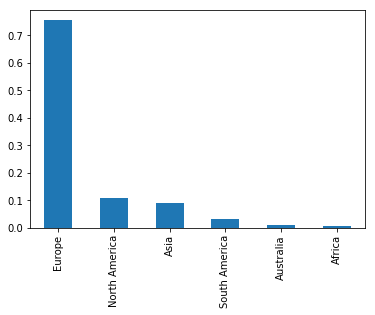

In [99]:
%matplotlib inline
output['CONTINENT_NAME'].value_counts(normalize=True).plot(kind='bar')

### Country data distribution

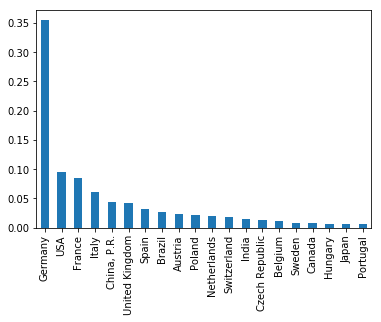

In [100]:
output['HOTEL_COUNTRY_NAME'].value_counts(normalize=True)[:20].plot(kind='bar')

#### To dataframe and df to dict

In [101]:
dist = output['HOTEL_COUNTRY_NAME'].value_counts(normalize = True).sort_values(ascending=False)
#dist_dict = dist.set_index('HOTEL_COUNTRY_NAME')['value'].to_dict()
dist = dist.to_frame()
dist = dist.reset_index()
dist.columns = ['country_name', 'data_share']
dist_dic = dict(zip(dist.country_name, dist.data_share))
dist_dic

{'Albania': 0.00019259038419061443,
 'Algeria': 0.00013274591452686418,
 'Andorra': 5.005173826422748e-05,
 'Angola': 7.072528232988665e-05,
 'Argentina': 0.0013372518766681645,
 'Armenia': 6.528487599681845e-05,
 'Aruba': 1.0880812666136409e-06,
 'Australia': 0.006095431255569616,
 'Austria': 0.02275177928489123,
 'Azerbaijan': 0.00012077702059411413,
 'Bahamas': 7.616568866295486e-06,
 'Bahrain': 0.0002372017161217737,
 'Bangladesh': 0.00017518108392479618,
 'Barbados': 5.440406333068204e-06,
 'Belarus': 0.0003253362987174786,
 'Belgium': 0.010505424629154702,
 'Belize': 1.0880812666136409e-06,
 'Benin': 4.461133193115927e-05,
 'Bermuda': 3.2642437998409226e-06,
 'Bhutan': 8.704650132909127e-06,
 'Birma (Burma) (Myanmar)': 0.00019803079052368262,
 'Bolivia': 0.00012295318312734142,
 'Bosnia and Herzegovina': 0.000309015079718274,
 'Botswana': 3.0466275465181945e-05,
 'Brazil': 0.027168301146075997,
 'Brunei': 1.6321218999204613e-05,
 'Bulgaria': 0.0014504123283959832,
 'Burkina Faso'

#### Merging the distribution

In [118]:
#dist = dist.reset_index()
#output = output.reset_index()
# output = output.merge(dist, left_on='HOTEL_COUNTRY_NAME', right_on='country_name')
display(output.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 919049 entries, 0 to 919048
Data columns (total 24 columns):
BOOKING_COUNT                919049 non-null int64
HOTEL_ID                     919049 non-null int64
HOTEL_COUNTRY_NAME           919049 non-null object
CONTINENT_NAME               919049 non-null object
HOTEL_CATEGORY_SHORT_DESC    919049 non-null object
HOTEL_CATEGORY_NUMBER        919049 non-null int64
HOTEL_COUNTRY_ID             919049 non-null int64
HOTEL_CITY_ID                919049 non-null int64
HOTEL_CATEGORY_ID            919049 non-null int64
ARR_YEAR                     919049 non-null int64
ARR_MONTH                    919049 non-null int64
BKG_YEAR                     919049 non-null int64
BKG_MONTH                    919049 non-null int64
TOVER                        919049 non-null float64
RNS                          919049 non-null int64
DOM_TRAV                     637998 non-null float64
INT_TRAV                     539327 non-null float64
UNKNOWN_TRAV 

None

#### HTML display

In [111]:
from IPython.display import display, HTML
display(HTML(output.drop_duplicates(['HOTEL_COUNTRY_NAME', 'data_share'])[['HOTEL_COUNTRY_NAME', 'data_share']].sort_values(by=['data_share'], ascending=False).to_html(index=False)))

HOTEL_COUNTRY_NAME,data_share
Germany,0.354030
USA,0.095553
France,0.084737
Italy,0.061235
"China, P.R.",0.043668
United Kingdom,0.042783
Spain,0.030931
Brazil,0.027168
Austria,0.022752
Poland,0.020794


In [153]:
#out_group = output.groupby(['HOTEL_COUNTRY_NAME','ARR_YEAR','ARR_MONTH','BKG_YEAR','BKG_MONTH'])["BOOKING_COUNT", "RNS", "DOM_TRAV", "INT_TRAV", "UNKNOWN_TRAV"].sum()
#out_group.info()
# out_group.iloc[out_group.index.get_level_values('HOTEL_COUNTRY_NAME') == "Germany"]
out_group.query('HOTEL_COUNTRY_NAME == "Germany"')

BOOKING_COUNT  \
HOTEL_COUNTRY_NAME ARR_YEAR ARR_MONTH BKG_YEAR BKG_MONTH                  
Germany            2019     1         2019     1                 381188   
                                               2                      1   
                            2         2019     1                 206316   
                                               2                 342505   
                                               3                      1   
                            3         2019     1                  66544   
                                               2                 191625   
                                               3                 365860   
                            4         2019     4                 292437   
                                               5                      2   
                            5         2019     4                 206553   
                                               5                 353320   
                                               6                      1   
                            6         2019     4                  50085   
                                               5                 196223   
                                               6                 296877   
                   2020     1         2020     1                 345358   
                            2         2020     1                 212085   
                                               2                 299274   
                            3         2020     1                  74406   
                                               2                 214052   
                                               3                 197943   
                            4         2020     4                  38745   
                            5         2020     4                  14632   
                                               5                  21386   
                            6         2020     4                   3604   
                                               5                   2908   

                                                             RNS  DOM_TRAV  \
HOTEL_COUNTRY_NAME ARR_YEAR ARR_MONTH BKG_YEAR BKG_MONTH                     
Germany            2019     1         2019     1          583496  350146.0   
                                               2               1       1.0   
                            2         2019     1          380217  186946.0   
                                               2          508709  312881.0   
                                               3               3       1.0   
                            3         2019     1          133641   62088.0   
                                               2          360943  172959.0   
                                               3          560273  335441.0   
                            4         2019     4          429399  270181.0   
                                               5               2       0.0   
                            5         2019     4          374408  187045.0   
                                               5          515948  325951.0   
                                               6               1       1.0   
                            6         2019     4          104989   46013.0   
                                               5          364599  176931.0   
                                               6          452084  275372.0   
                   2020     1         2020     1          533045  315269.0   
                            2         2020     1          394143  189928.0   
                                               2          450827  275061.0   
                            3         2020     1          152499   68948.0   
                                               2          399066  193717.0   
                                               3          329809  187022.0   
          

In [142]:
test = output.groupby('HOTEL_COUNTRY_NAME')
test.get_group("Germany")

KeyError: 'HOTEL_COUNTRY_NAME'